In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Bimbing Bootcamp/EC6/Assignment Day Extra Class 6 - People Analytics/assignment_employee_survey.csv')

In [3]:
print (f"Dataset shape: {df.shape}")

Dataset shape: (2766, 23)


In [4]:
df.head()

,emp_id,gender,age,marital_status,job_level,experience,dept,emp_type,wlb,work_env,...,sleep_hours,commute_mode,commute_distance,num_companies,team_size,num_reports,edu_level,have_ot,training_hours_per_year,job_satisfaction
0,6,Male,32,Married,Mid,7,IT,Full-Time,1,1,...,7.6,Car,20,3,12,0,Bachelor,True,33.5,5
1,11,Female,34,Married,Mid,12,Finance,Full-Time,1,1,...,7.9,Car,15,4,11,0,Bachelor,False,36.0,5
2,33,Female,23,Single,Intern/Fresher,1,Marketing,Full-Time,2,4,...,6.5,Motorbike,17,0,30,0,Bachelor,True,10.5,5
3,20,Female,29,Married,Junior,6,IT,Contract,2,2,...,7.5,Public Transport,13,2,9,0,Bachelor,True,23.0,5
4,45,Female,33,Married,Mid,10,Operations,Part-Time,2,3,...,6.2,Car,8,3,13,0,Bachelor,False,35.0,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   emp_id                   2766 non-null   int64  
 1   gender                   2766 non-null   object 
 2   age                      2766 non-null   int64  
 3   marital_status           2766 non-null   object 
 4   job_level                2766 non-null   object 
 5   experience               2766 non-null   int64  
 6   dept                     2766 non-null   object 
 7   emp_type                 2766 non-null   object 
 8   wlb                      2766 non-null   int64  
 9   work_env                 2766 non-null   int64  
 10  physical_activity_hours  2766 non-null   float64
 11  workload                 2766 non-null   int64  
 12  stress                   2766 non-null   int64  
 13  sleep_hours              2766 non-null   float64
 14  commute_mode            

In [6]:
df.describe()

,emp_id,age,experience,wlb,work_env,physical_activity_hours,workload,stress,sleep_hours,commute_distance,num_companies,team_size,num_reports,training_hours_per_year,job_satisfaction
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000
mean,1516.601952,35.650759,8.989154,3.049530,3.028923,2.038250,2.979031,1.737166,7.008351,13.419740,4.223066,16.491685,2.374187,37.220535,3.380694
std,873.996466,10.175719,7.003013,1.448103,1.417494,0.966535,1.405335,1.065303,1.003736,8.344388,3.377586,6.638354,3.055823,13.540622,1.267785
min,1.000000,22.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,4.000000,1.000000,0.000000,5.000000,0.000000,10.000000,1.000000
25%,764.500000,27.000000,3.000000,2.000000,2.000000,1.400000,2.000000,1.000000,6.300000,6.000000,1.000000,11.000000,0.000000,23.500000,3.000000
50%,1515.500000,34.000000,8.000000,3.000000,3.000000,2.100000,3.000000,1.000000,7.000000,13.000000,4.000000,16.000000,0.000000,39.500000,4.000000
75%,2271.750000,43.000000,14.000000,4.000000,4.000000,2.700000,4.000000,2.000000,7.700000,20.000000,7.000000,22.000000,5.000000,46.500000,4.000000
max,3025.000000,60.000000,29.000000,5.000000,5.000000,5.000000,5.000000,5.000000,10.000000,29.000000,12.000000,30.000000,9.000000,64.500000,5.000000


In [7]:
print("Missing value check")

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
    }).sort_values('Missing Count', ascending=False)



print(missing_df[missing_df['Missing Count'] > 0])
if missing_df['Missing Count'].sum() == 0:
    print("\n No missing values found!")


Missing value check
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

 No missing values found!


In [8]:
print("DATA TYPES & UNIQUE VALUES")

for col in df.columns:
    print(f"{col:30} | Type: {str(df[col].dtype):10} | Unique: {df[col].nunique():5}")

DATA TYPES & UNIQUE VALUES
emp_id                         | Type: int64      | Unique:  2766
gender                         | Type: object     | Unique:     2
age                            | Type: int64      | Unique:    39
marital_status                 | Type: object     | Unique:     3
job_level                      | Type: object     | Unique:     5
experience                     | Type: int64      | Unique:    30
dept                           | Type: object     | Unique:     8
emp_type                       | Type: object     | Unique:     3
wlb                            | Type: int64      | Unique:     5
work_env                       | Type: int64      | Unique:     5
physical_activity_hours        | Type: float64    | Unique:    51
workload                       | Type: int64      | Unique:     5
stress                         | Type: int64      | Unique:     5
sleep_hours                    | Type: float64    | Unique:    60
commute_mode                   | Type: object    

JOB SATISFACTION DISTRIBUTION
                  Count  Percentage
job_satisfaction                   
1                   388       14.03
2                   254        9.18
3                   519       18.76
4                  1127       40.74
5                   478       17.28

Mean Job Satisfaction: 3.38
Median Job Satisfaction: 4.00
Mode Job Satisfaction: 4


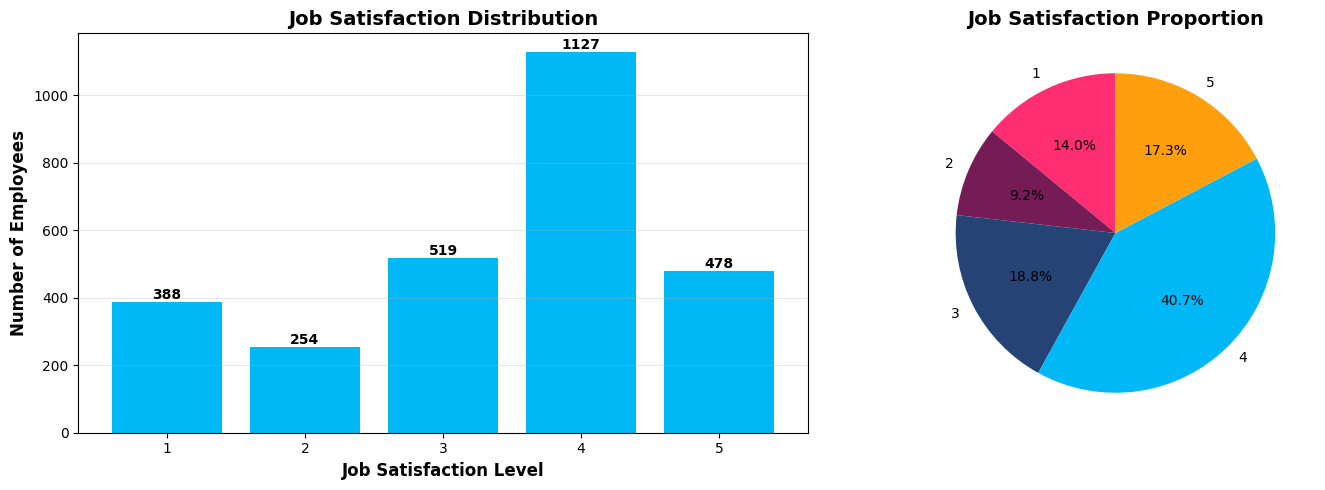

In [11]:
print("JOB SATISFACTION DISTRIBUTION")

satisfaction_dist = df['job_satisfaction'].value_counts().sort_index()
satisfaction_pct = (satisfaction_dist / len(df) * 100).round(2)

satisfaction_summary = pd.DataFrame({
    'Count': satisfaction_dist,
    'Percentage': satisfaction_pct
})

print(satisfaction_summary)
print(f"\nMean Job Satisfaction: {df['job_satisfaction'].mean():.2f}")
print(f"Median Job Satisfaction: {df['job_satisfaction'].median():.2f}")
print(f"Mode Job Satisfaction: {df['job_satisfaction'].mode()[0]}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(satisfaction_dist.index, satisfaction_dist.values,
            color=['#00b8f6'])
axes[0].set_xlabel('Job Satisfaction Level', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Employees', fontsize=12, fontweight='bold')
axes[0].set_title('Job Satisfaction Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(satisfaction_dist.values):
    axes[0].text(satisfaction_dist.index[i], v, str(v),
                ha='center', va='bottom', fontweight='bold')

colors_pie = ['#ff2d71', '#751b56', '#254375', '#00b8f6', '#ff9f0d']
axes[1].pie(satisfaction_dist.values, labels=satisfaction_dist.index,
           autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title('Job Satisfaction Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

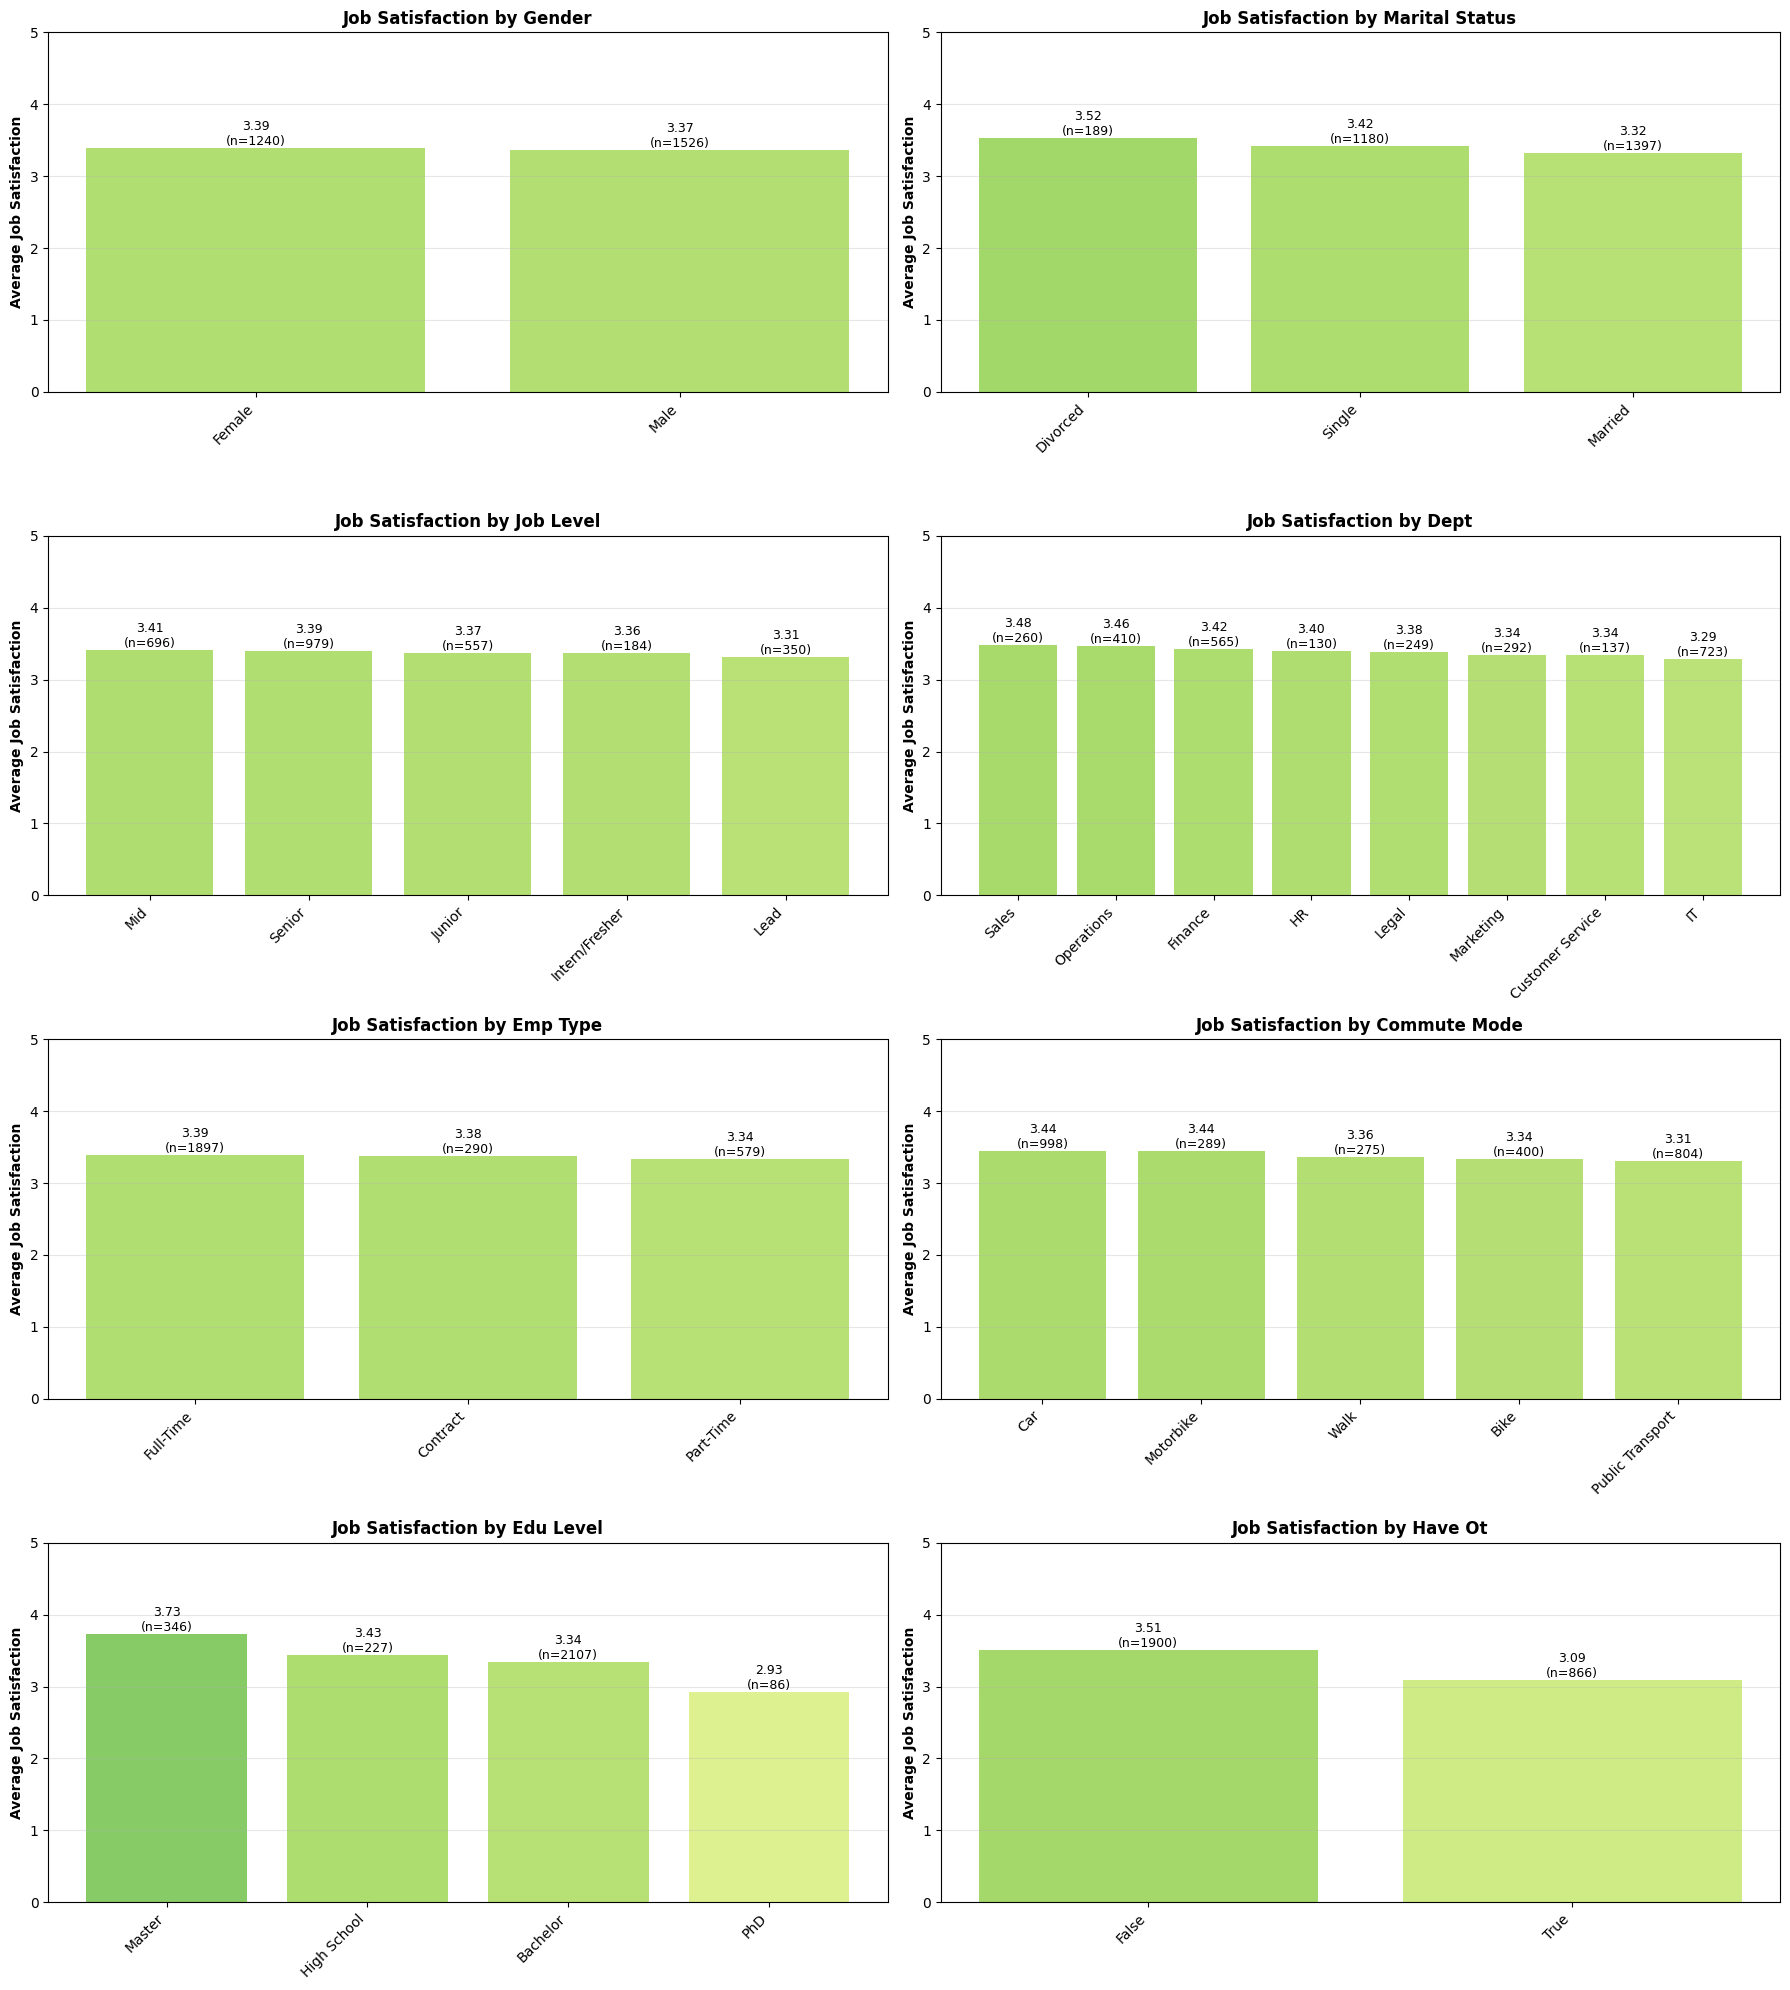

In [ ]:
categorical_vars = ['gender', 'marital_status', 'job_level', 'dept',
                    'emp_type', 'commute_mode', 'edu_level', 'have_ot']

fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.ravel()

for idx, var in enumerate(categorical_vars):
    satisfaction_by_cat = df.groupby(var)['job_satisfaction'].agg(['mean', 'count']).reset_index()
    satisfaction_by_cat = satisfaction_by_cat.sort_values('mean', ascending=False)

    bars = axes[idx].bar(range(len(satisfaction_by_cat)),
                         satisfaction_by_cat['mean'],
                         color=plt.cm.RdYlGn(satisfaction_by_cat['mean']/5))

    axes[idx].set_xticks(range(len(satisfaction_by_cat)))
    axes[idx].set_xticklabels(satisfaction_by_cat[var], rotation=45, ha='right')
    axes[idx].set_ylabel('Average Job Satisfaction', fontweight='bold')
    axes[idx].set_title(f'Job Satisfaction by {var.replace("_", " ").title()}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 5)
    axes[idx].grid(axis='y', alpha=0.3)

    for i, (bar, row) in enumerate(zip(bars, satisfaction_by_cat.itertuples())):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.2f}\n(n={row.count})',
                      ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

CORRELATION WITH JOB SATISFACTION
wlb                        0.256853
work_env                   0.244227
sleep_hours                0.177377
commute_distance           0.003727
team_size                  0.002718
num_companies             -0.008437
training_hours_per_year   -0.009717
age                       -0.011165
physical_activity_hours   -0.012094
experience                -0.013914
num_reports               -0.027634
stress                    -0.212416
workload                  -0.257175
Name: job_satisfaction, dtype: float64


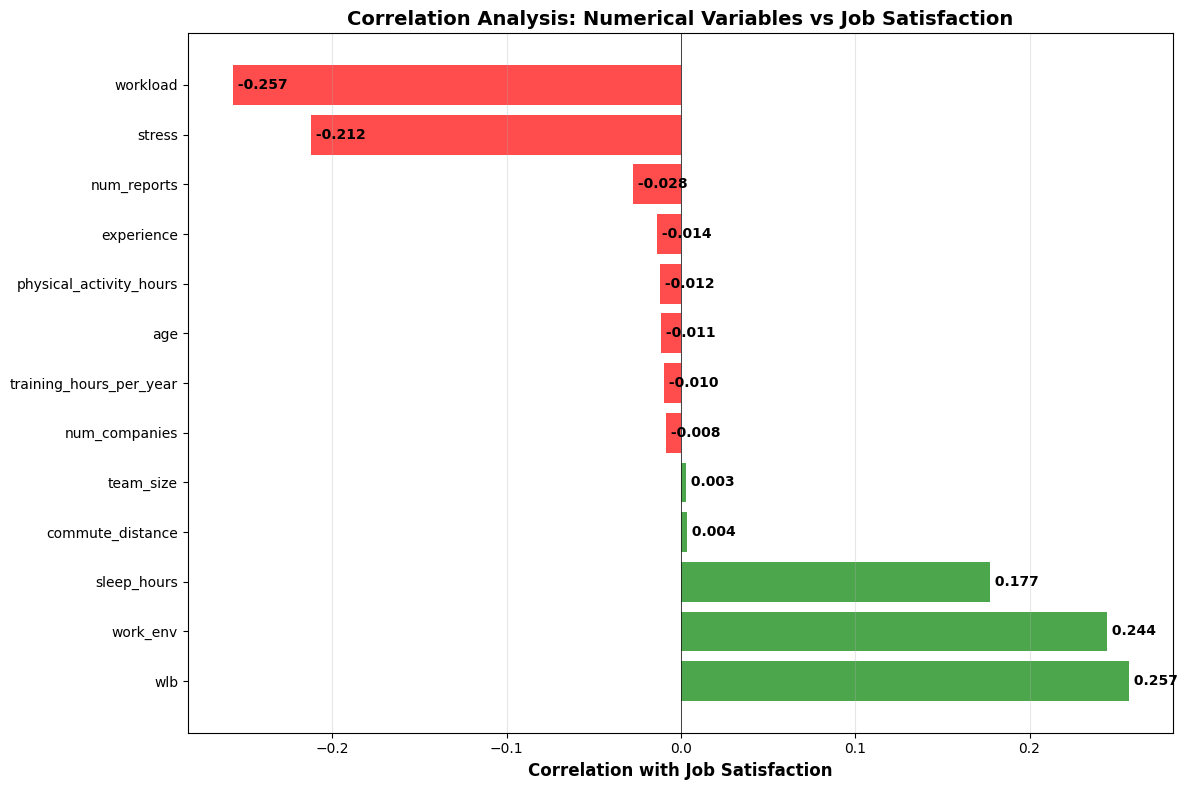

In [ ]:
numerical_vars = ['age', 'experience', 'wlb', 'work_env', 'physical_activity_hours',
                 'workload', 'stress', 'sleep_hours', 'commute_distance',
                 'num_companies', 'team_size', 'num_reports', 'training_hours_per_year']

print("CORRELATION WITH JOB SATISFACTION")

correlations = df[numerical_vars + ['job_satisfaction']].corr()['job_satisfaction'].drop('job_satisfaction')
correlations = correlations.sort_values(ascending=False)

print(correlations)

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
plt.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
plt.yticks(range(len(correlations)), correlations.index)
plt.xlabel('Correlation with Job Satisfaction', fontsize=12, fontweight='bold')
plt.title('Correlation Analysis: Numerical Variables vs Job Satisfaction',
         fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(correlations.values):
    plt.text(v, i, f' {v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

WORK-LIFE BALANCE IMPACT ANALYSIS
     Avg Satisfaction  Std Dev  Count  Avg Stress  Avg Sleep Hours
wlb                                                               
1                2.91     1.37    575        1.73             7.00
2                3.13     1.35    502        1.77             7.06
3                3.40     1.20    507        1.68             6.95
4                3.62     1.14    575        1.77             7.04
5                3.79     1.05    607        1.73             6.99


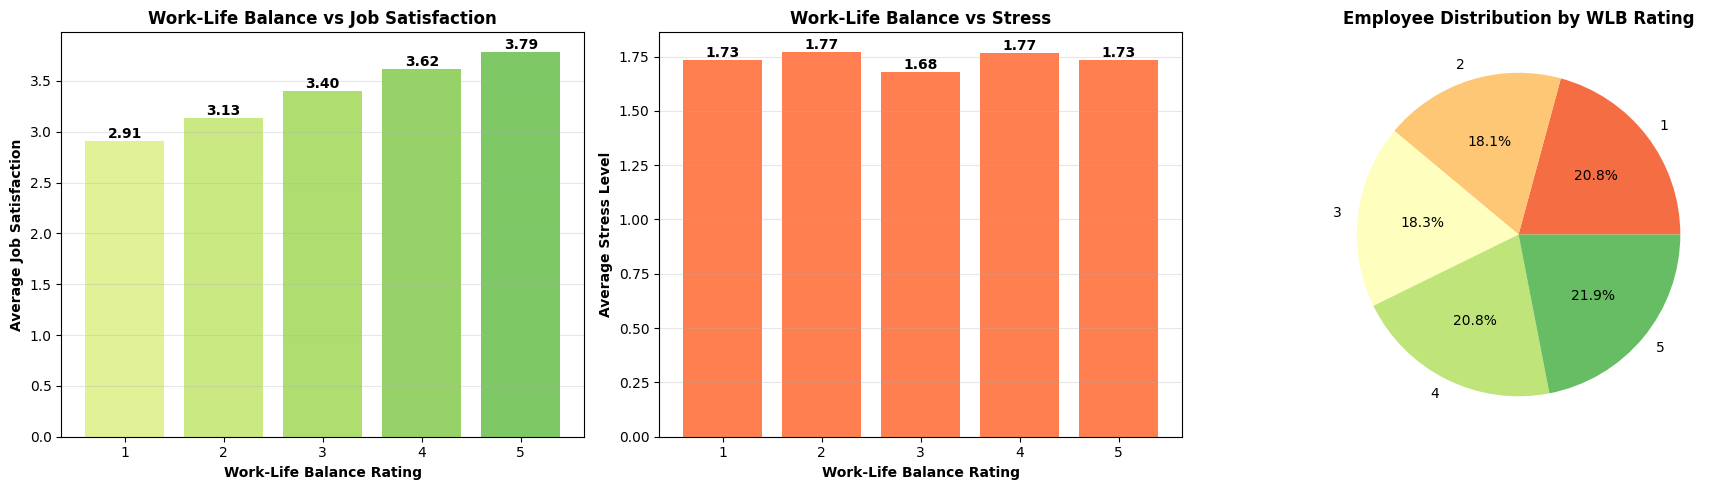

In [ ]:
print("WORK-LIFE BALANCE IMPACT ANALYSIS")

wlb_analysis = df.groupby('wlb').agg({
    'job_satisfaction': ['mean', 'std', 'count'],
    'stress': 'mean',
    'sleep_hours': 'mean'
}).round(2)

wlb_analysis.columns = ['Avg Satisfaction', 'Std Dev', 'Count', 'Avg Stress', 'Avg Sleep Hours']
print(wlb_analysis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

wlb_sat = df.groupby('wlb')['job_satisfaction'].mean()
bars1 = axes[0].bar(wlb_sat.index, wlb_sat.values, color=plt.cm.RdYlGn(wlb_sat.values/5))
axes[0].set_xlabel('Work-Life Balance Rating', fontweight='bold')
axes[0].set_ylabel('Average Job Satisfaction', fontweight='bold')
axes[0].set_title('Work-Life Balance vs Job Satisfaction', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

wlb_stress = df.groupby('wlb')['stress'].mean()
axes[1].bar(wlb_stress.index, wlb_stress.values, color='coral')
axes[1].set_xlabel('Work-Life Balance Rating', fontweight='bold')
axes[1].set_ylabel('Average Stress Level', fontweight='bold')
axes[1].set_title('Work-Life Balance vs Stress', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(wlb_stress.values):
    axes[1].text(wlb_stress.index[i], v, f'{v:.2f}',
                ha='center', va='bottom', fontweight='bold')

wlb_counts = df['wlb'].value_counts().sort_index()
axes[2].pie(wlb_counts.values, labels=wlb_counts.index, autopct='%1.1f%%',
           colors=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(wlb_counts))))
axes[2].set_title('Employee Distribution by WLB Rating', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

WORK ENVIRONMENT IMPACT ANALYSIS
          Avg Satisfaction  Std Dev  Count  Avg Workload  Avg Stress
work_env                                                            
1                     2.91     1.36    532          2.92        1.70
2                     3.19     1.29    554          3.05        1.80
3                     3.36     1.26    571          2.96        1.75
4                     3.63     1.17    520          3.02        1.72
5                     3.78     1.07    589          2.95        1.71


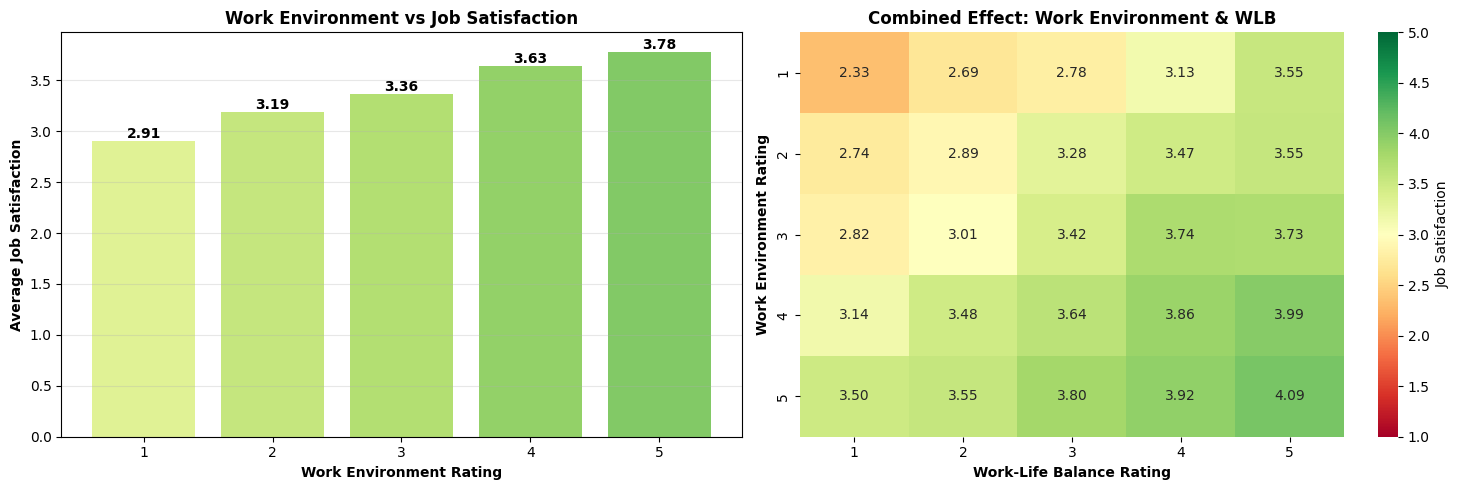

In [ ]:
print("WORK ENVIRONMENT IMPACT ANALYSIS")

workenv_analysis = df.groupby('work_env').agg({
    'job_satisfaction': ['mean', 'std', 'count'],
    'workload': 'mean',
    'stress': 'mean'
}).round(2)

workenv_analysis.columns = ['Avg Satisfaction', 'Std Dev', 'Count', 'Avg Workload', 'Avg Stress']
print(workenv_analysis)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

workenv_sat = df.groupby('work_env')['job_satisfaction'].mean()
bars = axes[0].bar(workenv_sat.index, workenv_sat.values,
                   color=plt.cm.RdYlGn(workenv_sat.values/5))
axes[0].set_xlabel('Work Environment Rating', fontweight='bold')
axes[0].set_ylabel('Average Job Satisfaction', fontweight='bold')
axes[0].set_title('Work Environment vs Job Satisfaction', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

pivot_data = df.pivot_table(values='job_satisfaction',
                            index='work_env',
                            columns='wlb',
                            aggfunc='mean')
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn',
           vmin=1, vmax=5, ax=axes[1], cbar_kws={'label': 'Job Satisfaction'})
axes[1].set_xlabel('Work-Life Balance Rating', fontweight='bold')
axes[1].set_ylabel('Work Environment Rating', fontweight='bold')
axes[1].set_title('Combined Effect: Work Environment & WLB', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

DEPARTMENT ANALYSIS
                  Avg Satisfaction  Std Dev  Headcount  Avg WLB  Avg Work Env  \
dept                                                                            
Sales                         3.48     1.16        260     3.17          3.03   
Operations                    3.46     1.25        410     3.05          3.10   
Finance                       3.42     1.27        565     3.08          3.02   
HR                            3.40     1.26        130     2.81          3.10   
Legal                         3.38     1.21        249     3.06          3.02   
Customer Service              3.34     1.27        137     2.77          2.94   
Marketing                     3.34     1.30        292     3.12          2.75   
IT                            3.29     1.32        723     3.04          3.12   

                  Avg Stress  Avg Training Hours  
dept                                              
Sales                   1.77               36.91  
Operations      

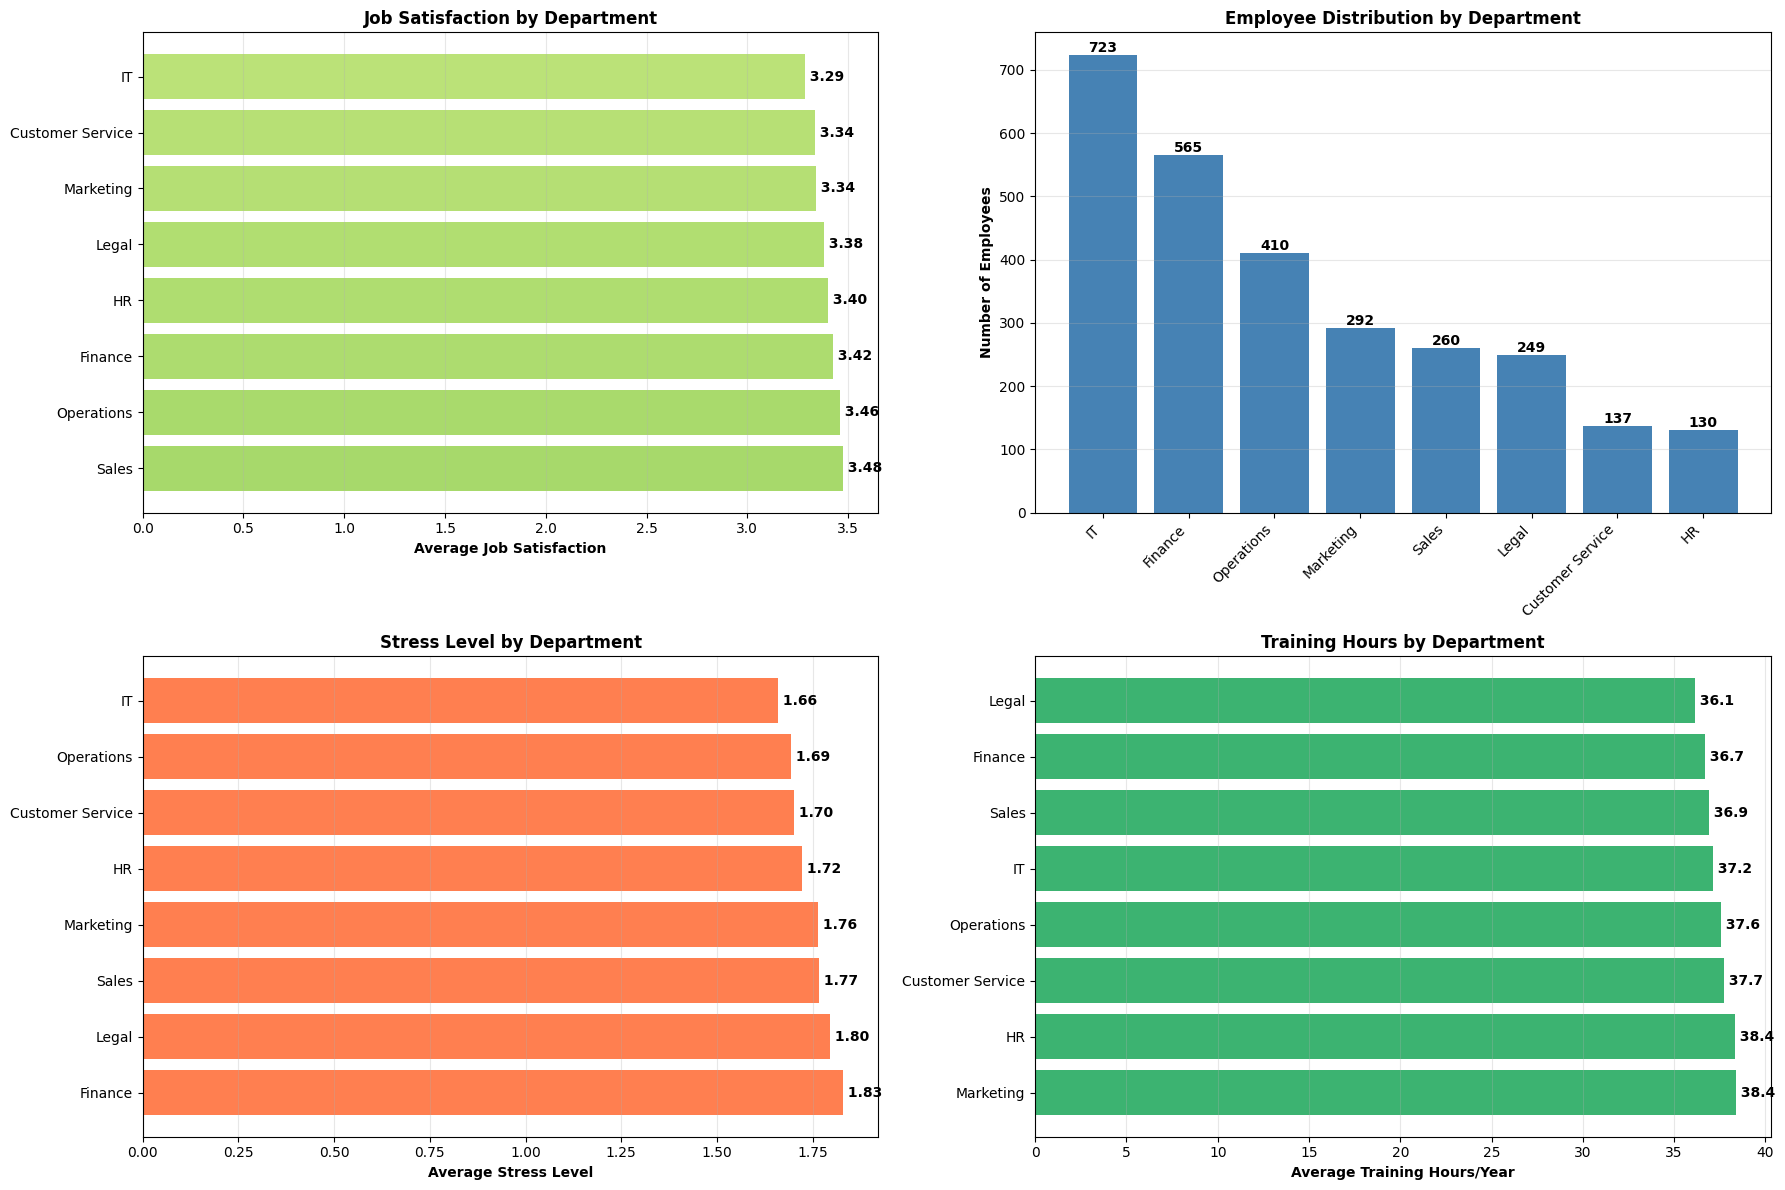

In [ ]:
print("DEPARTMENT ANALYSIS")

dept_analysis = df.groupby('dept').agg({
    'job_satisfaction': ['mean', 'std', 'count'],
    'wlb': 'mean',
    'work_env': 'mean',
    'stress': 'mean',
    'training_hours_per_year': 'mean'
}).round(2)

dept_analysis.columns = ['Avg Satisfaction', 'Std Dev', 'Headcount',
                         'Avg WLB', 'Avg Work Env', 'Avg Stress', 'Avg Training Hours']
dept_analysis = dept_analysis.sort_values('Avg Satisfaction', ascending=False)
print(dept_analysis)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

dept_sat = df.groupby('dept')['job_satisfaction'].mean().sort_values(ascending=False)
bars = axes[0, 0].barh(range(len(dept_sat)), dept_sat.values,
                       color=plt.cm.RdYlGn(dept_sat.values/5))
axes[0, 0].set_yticks(range(len(dept_sat)))
axes[0, 0].set_yticklabels(dept_sat.index)
axes[0, 0].set_xlabel('Average Job Satisfaction', fontweight='bold')
axes[0, 0].set_title('Job Satisfaction by Department', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(dept_sat.values):
    axes[0, 0].text(v, i, f' {v:.2f}', va='center', fontweight='bold')

dept_count = df['dept'].value_counts()
axes[0, 1].bar(range(len(dept_count)), dept_count.values, color='steelblue')
axes[0, 1].set_xticks(range(len(dept_count)))
axes[0, 1].set_xticklabels(dept_count.index, rotation=45, ha='right')
axes[0, 1].set_ylabel('Number of Employees', fontweight='bold')
axes[0, 1].set_title('Employee Distribution by Department', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(dept_count.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

dept_stress = df.groupby('dept')['stress'].mean().sort_values(ascending=False)
axes[1, 0].barh(range(len(dept_stress)), dept_stress.values, color='coral')
axes[1, 0].set_yticks(range(len(dept_stress)))
axes[1, 0].set_yticklabels(dept_stress.index)
axes[1, 0].set_xlabel('Average Stress Level', fontweight='bold')
axes[1, 0].set_title('Stress Level by Department', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(dept_stress.values):
    axes[1, 0].text(v, i, f' {v:.2f}', va='center', fontweight='bold')

dept_training = df.groupby('dept')['training_hours_per_year'].mean().sort_values(ascending=False)
axes[1, 1].barh(range(len(dept_training)), dept_training.values, color='mediumseagreen')
axes[1, 1].set_yticks(range(len(dept_training)))
axes[1, 1].set_yticklabels(dept_training.index)
axes[1, 1].set_xlabel('Average Training Hours/Year', fontweight='bold')
axes[1, 1].set_title('Training Hours by Department', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(dept_training.values):
    axes[1, 1].text(v, i, f' {v:.1f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:

print("EMPLOYEE SEGMENTATION BY SATISFACTION LEVEL")
df['satisfaction_segment'] = pd.cut(df['job_satisfaction'],
                                    bins=[0, 2, 3, 4, 5],
                                    labels=['Low (1-2)', 'Medium (3)', 'High (4)', 'Very High (5)'])

segment_analysis = df.groupby('satisfaction_segment').agg({
    'emp_id': 'count',
    'wlb': 'mean',
    'work_env': 'mean',
    'stress': 'mean',
    'training_hours_per_year': 'mean',
    'experience': 'mean'
}).round(2)

segment_analysis.columns = ['Count', 'Avg WLB', 'Avg Work Env',
                           'Avg Stress', 'Avg Training', 'Avg Experience']
print(segment_analysis)


print("\nPROFILE OF LOW SATISFACTION EMPLOYEES")

low_satisfaction = df[df['job_satisfaction'] <= 2]
print(f"\nTotal Low Satisfaction Employees: {len(low_satisfaction)}")
print(f"Percentage of total: {len(low_satisfaction)/len(df)*100:.2f}%")

print("\nDepartment Distribution:")
print(low_satisfaction['dept'].value_counts())

print("\nJob Level Distribution:")
print(low_satisfaction['job_level'].value_counts())

print("\nKey Metrics Comparison:")
comparison_df = pd.DataFrame({
    'Low Satisfaction': [
        low_satisfaction['wlb'].mean(),
        low_satisfaction['work_env'].mean(),
        low_satisfaction['stress'].mean(),
        low_satisfaction['training_hours_per_year'].mean()
    ],
    'Overall Average': [
        df['wlb'].mean(),
        df['work_env'].mean(),
        df['stress'].mean(),
        df['training_hours_per_year'].mean()
    ]
}, index=['WLB', 'Work Environment', 'Stress', 'Training Hours'])

comparison_df['Difference'] = comparison_df['Low Satisfaction'] - comparison_df['Overall Average']
print(comparison_df.round(2))

EMPLOYEE SEGMENTATION BY SATISFACTION LEVEL
                      Count  Avg WLB  Avg Work Env  Avg Stress  Avg Training  \
satisfaction_segment                                                           
Low (1-2)               642     2.56          2.66        2.06         37.48   
Medium (3)              519     2.83          2.59        1.90         36.91   
High (4)               1127     3.24          3.26        1.55         37.27   
Very High (5)           478     3.50          3.45        1.57         37.09   

                      Avg Experience  
satisfaction_segment                  
Low (1-2)                       9.03  
Medium (3)                      9.01  
High (4)                        9.10  
Very High (5)                   8.65  

PROFILE OF LOW SATISFACTION EMPLOYEES

Total Low Satisfaction Employees: 642
Percentage of total: 23.21%

Department Distribution:
dept
IT                  183
Finance             129
Operations           91
Marketing            73
Legal   

/tmp/ipython-input-191027735.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby('satisfaction_segment').agg({


In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("STATISTICAL SIGNIFICANCE TESTS")

high_wlb = df[df['wlb'] >= 4]['job_satisfaction']
low_wlb = df[df['wlb'] <= 2]['job_satisfaction']
t_stat_wlb, p_value_wlb = stats.ttest_ind(high_wlb, low_wlb)

print("\n1. Work-Life Balance Impact:")
print(f"   High WLB (4-5) avg satisfaction: {high_wlb.mean():.2f}")
print(f"   Low WLB (1-2) avg satisfaction: {low_wlb.mean():.2f}")
print(f"   T-statistic: {t_stat_wlb:.4f}")
print(f"   P-value: {p_value_wlb:.6f}")
print(f"   Significant: {'YES' if p_value_wlb < 0.05 else 'NO'}")

high_env = df[df['work_env'] >= 4]['job_satisfaction']
low_env = df[df['work_env'] <= 2]['job_satisfaction']
t_stat_env, p_value_env = stats.ttest_ind(high_env, low_env)

print("\n2. Work Environment Impact:")
print(f"   High Work Env (4-5) avg satisfaction: {high_env.mean():.2f}")
print(f"   Low Work Env (1-2) avg satisfaction: {low_env.mean():.2f}")
print(f"   T-statistic: {t_stat_env:.4f}")
print(f"   P-value: {p_value_env:.6f}")
print(f"   Significant: {'YES' if p_value_env < 0.05 else 'NO'}")

high_training = df[df['training_hours_per_year'] >= df['training_hours_per_year'].median()]['job_satisfaction']
low_training = df[df['training_hours_per_year'] < df['training_hours_per_year'].median()]['job_satisfaction']
t_stat_training, p_value_training = stats.ttest_ind(high_training, low_training)

print("\n3. Training Hours Impact:")
print(f"   High Training (≥median) avg satisfaction: {high_training.mean():.2f}")
print(f"   Low Training (<median) avg satisfaction: {low_training.mean():.2f}")
print(f"   T-statistic: {t_stat_training:.4f}")
print(f"   P-value: {p_value_training:.6f}")
print(f"   Significant: {'YES' if p_value_training < 0.05 else 'NO'}")

STATISTICAL SIGNIFICANCE TESTS

1. Work-Life Balance Impact:
   High WLB (4-5) avg satisfaction: 3.71
   Low WLB (1-2) avg satisfaction: 3.01
   T-statistic: 13.3686
   P-value: 0.000000
   Significant: YES

2. Work Environment Impact:
   High Work Env (4-5) avg satisfaction: 3.71
   Low Work Env (1-2) avg satisfaction: 3.05
   T-statistic: 12.6096
   P-value: 0.000000
   Significant: YES

3. Training Hours Impact:
   High Training (≥median) avg satisfaction: 3.37
   Low Training (<median) avg satisfaction: 3.40
   T-statistic: -0.6119
   P-value: 0.540621
   Significant: NO


In [ ]:
df.to_csv('employee_survey_cleaned.csv', index=False)

dept_analysis.to_csv('department_summary.csv')

correlation_matrix = df[numerical_vars + ['job_satisfaction']].corr()
correlation_matrix.to_csv('correlation_matrix.csv')

segment_analysis.to_csv('satisfaction_segments.csv')